In [6]:
pip install biopython numpy pandas scikit-learn imbalanced-learn matplotlib

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Reading the sample file

In [8]:
from Bio import SeqIO
fasta_file = r"C:\Users\96653\Desktop\Graduation Project\seqAnalysis\output.msa\output.msa"
records = list(SeqIO.parse(fasta_file, "fasta"))
print("Reference sequence name:", records[0].id)
print("Total number of sequences (including reference):", len(records))


Reference sequence name: NC_045512.2
Total number of sequences (including reference): 27112


# Mutation extraction

In [9]:
import pandas as pd
from Bio import AlignIO

alignment = AlignIO.read(r"C:\Users\96653\Desktop\Graduation Project\seqAnalysis\output.msa\output.msa", "fasta")
reference_sequence = alignment[0].seq
all_snps = []

# مقارنة كل تسلسل مع المرجع واستخراج فقط الطفرات من نوع Substitution (SNPs)
for sample in alignment[1:]:  # تجاوز المرجع
    for position, (ref_base, sample_base) in enumerate(zip(reference_sequence, sample.seq)):
        if ref_base == "-" or sample_base == "-":
            continue  
        if ref_base != sample_base:
            snp_info = {
                "Sample_ID": sample.id,
                "Position": position + 1,
                "Reference_Base": ref_base,
                "Sample_Base": sample_base,
                "Mutation_Type": "Substitution"
            }
            all_snps.append(snp_info)

snp_table = pd.DataFrame(all_snps)
print(snp_table.head(10))
print(f"\nTotal number of SNPs detected: {len(snp_table)}")
snp_table.to_csv("snp_table.csv", index=False, encoding='utf-8-sig')


    Sample_ID  Position Reference_Base Sample_Base Mutation_Type
0  PX255270.1        72              c           t  Substitution
1  PX255270.1        95              c           t  Substitution
2  PX255270.1       292              c           t  Substitution
3  PX255270.1       721              t           g  Substitution
4  PX255270.1       948              c           a  Substitution
5  PX255270.1      2841              c           t  Substitution
6  PX255270.1      3088              c           t  Substitution
7  PX255270.1      3491              g           t  Substitution
8  PX255270.1      3625              t           c  Substitution
9  PX255270.1      4244              g           a  Substitution

Total number of SNPs detected: 2153496


# Analysis of mutations and locus diversity using relative frequency and entropy (Shannon Entropy)

In [10]:
from Bio import AlignIO
from collections import Counter
import math
import pandas as pd

alignment = AlignIO.read(r"C:\Users\96653\Desktop\Graduation Project\seqAnalysis\output.msa\output.msa", "fasta")
alignment_length = alignment.get_alignment_length()
num_samples = len(set(snp_table["Sample_ID"]))

# Calculate the number of occurrences of each mutation according to position and symbol
allele_freq = snp_table.groupby(["Position", "Reference_Base", "Sample_Base"]).size().reset_index(name="Count")

#  (allele frequency)
allele_freq["Allele_Frequency"] = allele_freq["Count"] / num_samples

#  MAF
def classify_maf(freq):
    if freq < 0.01:
        return "Rare"
    elif freq < 0.05:
        return "Low-frequency"
    else:
        return "Common"

allele_freq["Frequency_Class"] = allele_freq["Allele_Frequency"].apply(classify_maf)

#  Shannon Entropy 
def shannon_entropy(column):
    counts = Counter(column)
    total = sum(counts.values())
    entropy = 0.0
    for base in counts:
        p = counts[base] / total
        entropy -= p * math.log2(p)
    return entropy

entropy_scores = []
for i in range(alignment_length):
    column = [record.seq[i] for record in alignment]
    entropy_scores.append(shannon_entropy(column))

# # Merging entropy values with the mutation table by position
entropy_df = pd.DataFrame({
    "Position": list(range(1, alignment_length + 1)),
    "Shannon_Entropy": entropy_scores
})

# Entropy classification: Conserved if less than 1.0
entropy_df["Entropy_Class"] = entropy_df["Shannon_Entropy"].apply(lambda x: "Conserved" if x < 1.0 else "Variable")

# Combining mutation tables with entropy data
merged_df = pd.merge(allele_freq, entropy_df, on="Position", how="left")

merged_df.to_csv("allele_frequencies_with_entropy.csv", index=False)

print(merged_df.head())
merged_df

   Position Reference_Base Sample_Base  Count  Allele_Frequency  \
0        51              a           c      1          0.000038   
1        51              a           g      2          0.000075   
2        52              t           c     11          0.000413   
3        52              t           n     12          0.000451   
4        53              t           c      1          0.000038   

  Frequency_Class  Shannon_Entropy Entropy_Class  
0            Rare         0.204475     Conserved  
1            Rare         0.204475     Conserved  
2            Rare         0.233092     Conserved  
3            Rare         0.233092     Conserved  
4            Rare         0.362949     Conserved  


,Position,Reference_Base,Sample_Base,Count,Allele_Frequency,Frequency_Class,Shannon_Entropy,Entropy_Class
0,51,a,c,1,0.000038,Rare,0.204475,Conserved
1,51,a,g,2,0.000075,Rare,0.204475,Conserved
2,52,t,c,11,0.000413,Rare,0.233092,Conserved
3,52,t,n,12,0.000451,Rare,0.233092,Conserved
4,53,t,c,1,0.000038,Rare,0.362949,Conserved
...,...,...,...,...,...,...,...,...
25021,30104,a,t,1,0.000038,Rare,0.010475,Conserved
25022,30105,a,c,5,0.000188,Rare,0.013604,Conserved
25023,30105,a,g,1,0.000038,Rare,0.013604,Conserved
25024,30105,a,n,2,0.000075,Rare,0.013604,Conserved


In [12]:
#29 Common SNPs with high Shannon entropy

#This means the mutation is common and diverse; it could be an evolutionary hotspot.

entropy_threshold = 1.0  # اعتبرنا "High" إذا الانتروبي ≥ 1.0

evolutionary_snps = merged_df[
    (merged_df["Frequency_Class"] == "Common") &
    (merged_df["Shannon_Entropy"] >= entropy_threshold)
]

print(evolutionary_snps.head(10))

print(f"\nTotal evolutionary-relevant SNPs detected: {len(evolutionary_snps)}")

evolutionary_snps.to_csv("evolutionary_snps.csv", index=False, encoding='utf-8-sig')
evolutionary_snps

       Position Reference_Base Sample_Base  Count  Allele_Frequency  \
73           95              c           t   4230          0.158981   
16483     21698              t           c   8148          0.306235   
16504     21719              c           g   2176          0.081783   
16505     21719              c           t  16789          0.630999   
16915     22088              g           a  18684          0.702221   
16997     22133              t           c   9798          0.368249   
16999     22134              c           a  10128          0.380652   
17003     22135              a           g   9694          0.364340   
17193     22322              t           g  16627          0.624911   
17632     22742              g           c   6680          0.251062   

      Frequency_Class  Shannon_Entropy Entropy_Class  
73             Common         1.461497      Variable  
16483          Common         1.095808      Variable  
16504          Common         1.266849      Variable 

,Position,Reference_Base,Sample_Base,Count,Allele_Frequency,Frequency_Class,Shannon_Entropy,Entropy_Class
73,95,c,t,4230,0.158981,Common,1.461497,Variable
16483,21698,t,c,8148,0.306235,Common,1.095808,Variable
16504,21719,c,g,2176,0.081783,Common,1.266849,Variable
16505,21719,c,t,16789,0.630999,Common,1.266849,Variable
16915,22088,g,a,18684,0.702221,Common,1.160225,Variable
16997,22133,t,c,9798,0.368249,Common,1.295168,Variable
16999,22134,c,a,10128,0.380652,Common,1.304590,Variable
17003,22135,a,g,9694,0.364340,Common,1.291807,Variable
17193,22322,t,g,16627,0.624911,Common,1.043769,Variable
17632,22742,g,c,6680,0.251062,Common,1.049708,Variable


# Table showing the types of gene regions

In [8]:
import pandas as pd

# Load the merged SNP dataset (assumed to have columns like Frequency_Class, Shannon_Entropy, Position, etc.)
file_path = r"C:\Users\96653\Desktop\Graduation Project\seqAnalysis\evolutionary_snps.csv"
df = pd.read_csv(file_path)

# Define gene regions
GENE_REGIONS = {
    "5'UTR": (1, 265),
    "ORF1ab": (266, 21555),
    "S": (21563, 25384),
    "ORF3a": (25393, 26220),
    "E": (26245, 26472),
    "M": (26523, 27191),
    "ORF6": (27202, 27387),
    "ORF7a": (27394, 27759),
    "ORF7b": (27756, 27887),
    "ORF8": (27894, 28259),
    "N": (28274, 29533),
    "ORF10": (29558, 29674),
    "3'UTR": (29675, 29903)
}

# Function to assign gene name to a mutation position
def assign_gene(position):
    for gene, (start, end) in GENE_REGIONS.items():
        if start <= position <= end:
            return gene
    return "Unknown"

# Apply gene assignment
df["Gene_Region"] = df["Position"].apply(assign_gene)

# Save updated dataset
df.to_csv(r"C:\Users\96653\Desktop\Graduation Project\seqAnalysis\evolutionary_snps.csv", index=False, encoding="utf-8-sig")

# Show preview
df


,Position,Reference_Base,Sample_Base,Count,Allele_Frequency,Frequency_Class,Shannon_Entropy,Entropy_Class,Gene_Region
0,95,c,t,4230,0.158981,Common,1.461497,Variable,5'UTR
1,21698,t,c,8148,0.306235,Common,1.095808,Variable,S
2,21719,c,g,2176,0.081783,Common,1.266849,Variable,S
3,21719,c,t,16789,0.630999,Common,1.266849,Variable,S
4,22088,g,a,18684,0.702221,Common,1.160225,Variable,S
5,22133,t,c,9798,0.368249,Common,1.295168,Variable,S
6,22134,c,a,10128,0.380652,Common,1.304590,Variable,S
7,22135,a,g,9694,0.364340,Common,1.291807,Variable,S
8,22322,t,g,16627,0.624911,Common,1.043769,Variable,S
9,22742,g,c,6680,0.251062,Common,1.049708,Variable,S


# Ranking the top 10 mutations by frequency in descending order

In [13]:
evolutionary_snps_sorted = evolutionary_snps.sort_values(by="Allele_Frequency", ascending=False)

top_10_snps = evolutionary_snps_sorted.head(10)

print(top_10_snps[["Position", "Reference_Base", "Sample_Base", "Count", "Allele_Frequency", "Shannon_Entropy"]])
top_10_snps

       Position Reference_Base Sample_Base  Count  Allele_Frequency  \
23726     29077              g           a  20736          0.779344   
23051     28467              a           t  19071          0.716766   
16915     22088              g           a  18684          0.702221   
17901     23060              t           g  16949          0.637013   
16505     21719              c           t  16789          0.630999   
17193     22322              t           g  16627          0.624911   
21847     27417              a           c  14520          0.545721   
17931     23085              t           a  12552          0.471756   
17879     23041              g           a  12488          0.469350   
21962     27542              t           c  12412          0.466494   

       Shannon_Entropy  
23726         1.012188  
23051         1.154099  
16915         1.160225  
17901         1.135386  
16505         1.266849  
17193         1.043769  
21847         1.005113  
17931         1.16

,Position,Reference_Base,Sample_Base,Count,Allele_Frequency,Frequency_Class,Shannon_Entropy,Entropy_Class
23726,29077,g,a,20736,0.779344,Common,1.012188,Variable
23051,28467,a,t,19071,0.716766,Common,1.154099,Variable
16915,22088,g,a,18684,0.702221,Common,1.160225,Variable
17901,23060,t,g,16949,0.637013,Common,1.135386,Variable
16505,21719,c,t,16789,0.630999,Common,1.266849,Variable
17193,22322,t,g,16627,0.624911,Common,1.043769,Variable
21847,27417,a,c,14520,0.545721,Common,1.005113,Variable
17931,23085,t,a,12552,0.471756,Common,1.166085,Variable
17879,23041,g,a,12488,0.469350,Common,1.006532,Variable
21962,27542,t,c,12412,0.466494,Common,1.002080,Variable


# A table showing the names of mutations, sorted in descending order by allele frequency.

In [15]:
import pandas as pd

def filter_significant_snps(df, maf_threshold=0.05, entropy_threshold=1.0):
    significant_snps = df[
        (df["Allele_Frequency"] >= maf_threshold) &
        (df["Shannon_Entropy"] >= entropy_threshold)
    ].copy()

    significant_snps["Mutation_ID"] = (
        significant_snps["Reference_Base"] +
        significant_snps["Position"].astype(str) +
        significant_snps["Sample_Base"]
    )

    significant_snps.sort_values(by=["Allele_Frequency", "Shannon_Entropy"], ascending=[False, False], inplace=True)

    return significant_snps

smart_snps = filter_significant_snps(merged_df)

print(smart_snps[["Mutation_ID", "Count", "Allele_Frequency", "Shannon_Entropy"]].head(29))

smart_snps.to_csv("smart_significant_snps.csv", index=False, encoding='utf-8-sig')

      Mutation_ID  Count  Allele_Frequency  Shannon_Entropy
23726     g29077a  20736          0.779344         1.012188
23051     a28467t  19071          0.716766         1.154099
16915     g22088a  18684          0.702221         1.160225
17901     t23060g  16949          0.637013         1.135386
16505     c21719t  16789          0.630999         1.266849
17193     t22322g  16627          0.624911         1.043769
21847     a27417c  14520          0.545721         1.005113
17931     t23085a  12552          0.471756         1.166085
17879     g23041a  12488          0.469350         1.006532
21962     t27542c  12412          0.466494         1.002080
21957     g27540c  12407          0.466306         1.006073
21961     a27541t  12405          0.466231         1.004984
18548     c23747g  11866          0.445973         1.533051
16999     c22134a  10128          0.380652         1.304590
18040     t23161c   9993          0.375578         1.496473
16997     t22133c   9798          0.3682

In [ ]:
# Core gene boundaries according to the reference NC_045512
GENE_REGIONS = {
    "5'UTR": (1, 265),
    "ORF1ab": (266, 21555),
    "S": (21563, 25384),
    "ORF3a": (25393, 26220),
    "E": (26245, 26472),
    "M": (26523, 27191),
    "ORF6": (27202, 27387),
    "ORF7a": (27394, 27759),
    "ORF7b": (27756, 27887),
    "ORF8": (27894, 28259),
    "N": (28274, 29533),
    "ORF10": (29558, 29674),
    "3'UTR": (29675, 29903)
}

C:\Users\96653\AppData\Local\Temp\ipykernel_5148\1691582311.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab20', len(GENE_REGIONS))


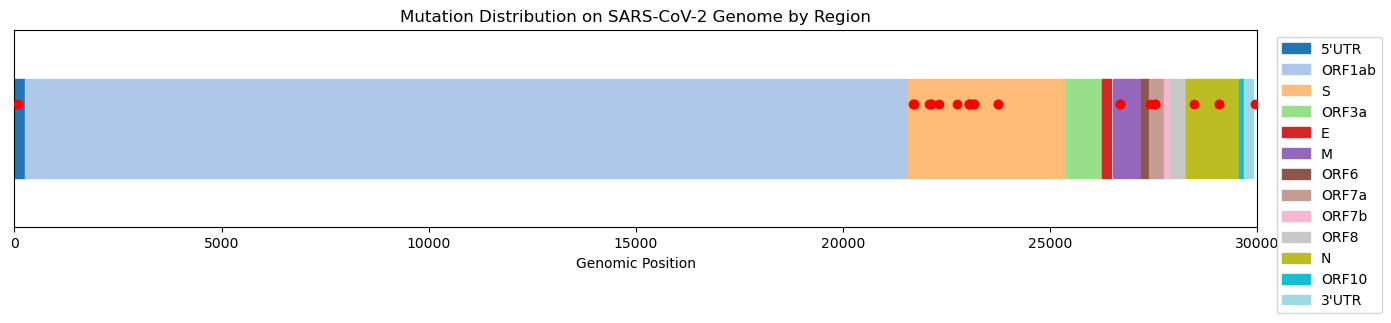

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# List of mutations locations
positions = [29077, 28467, 22088, 23060, 21719, 22322, 27417, 23085,
             23041, 27542, 27540, 27541, 23747, 22134, 23161, 22133,
             22135, 26687, 23747, 21698, 23039, 22742, 23161, 26687,
             95, 29943, 29077, 21719, 23039]

GENE_REGIONS = {
    "5'UTR": (1, 265),
    "ORF1ab": (266, 21555),
    "S": (21563, 25384),
    "ORF3a": (25393, 26220),
    "E": (26245, 26472),
    "M": (26523, 27191),
    "ORF6": (27202, 27387),
    "ORF7a": (27394, 27759),
    "ORF7b": (27756, 27887),
    "ORF8": (27894, 28259),
    "N": (28274, 29533),
    "ORF10": (29558, 29674),
    "3'UTR": (29675, 29903)
}

fig, ax = plt.subplots(figsize=(14, 3))

# Draw the genetic regions as colored rectangles
colors = plt.cm.get_cmap('tab20', len(GENE_REGIONS))
for i, (gene, (start, end)) in enumerate(GENE_REGIONS.items()):
    ax.add_patch(patches.Rectangle((start, 0.9), end - start, 0.2,
                                   color=colors(i), label=gene))

# Drawing mutations as points
ax.scatter(positions, [1.05]*len(positions), color='red', zorder=5)

ax.set_xlim(0, 30000)
ax.set_ylim(0.8, 1.2)
ax.set_yticks([])
ax.set_xlabel("Genomic Position")
ax.set_title("Mutation Distribution on SARS-CoV-2 Genome by Region")
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()
